In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
pd.set_option("display.max_columns", None)      # view ALL columns in DataFrames
# pd.reset_option("display.max_columns")        # reset to default
from drawarrow import ax_arrow
from highlight_text import fig_text, ax_text
# personalisation
plt.rcParams.update({
    "font.family": "Georgia",
    "font.size": 11,
    "lines.linewidth": 1,
})

# Import Data

In [9]:
df = pd.read_parquet("../data/strava_activities.parquet")

keep = [
    "activity_id", "name", "type",
    "start_datetime", "end_datetime",
    "date", "month", "weekday", "start_hour",
    "distance_km", "distance_miles",
    "moving_time_mins", "elapsed_time_mins",
    "avg_pace_km", "avg_pace_mile",
    "avg_hr", "max_hr", "avg_cadence_spm",
    "total_elev_gain",
    "shoe", "num_comments", "num_achievements", "num_kudos"
]

df = df[keep]

# filter to running activities only
df = df[df["type"] == "Run"]

# Kernel Density Estimation (KDE) Plot

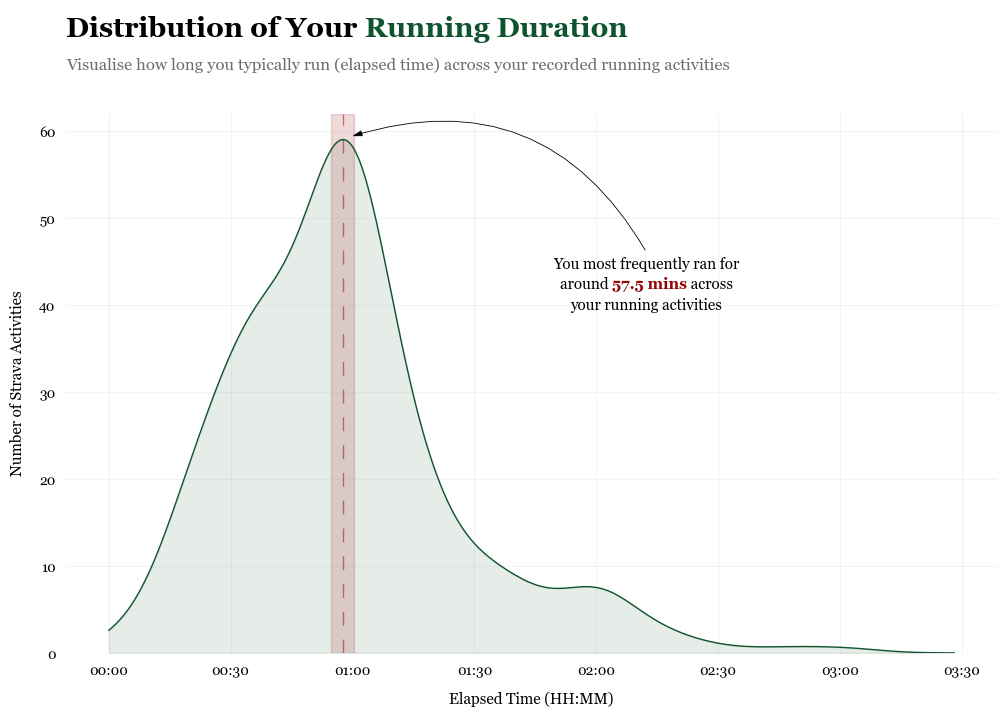

In [49]:
# choose colours
line_colour = "#0F542FFF"
avg_colour = "#950404FF"

# create a figure for visualisation
fig, ax = plt.subplots(figsize=(12, 7))

# axes customisation
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)    # remove all plot borders
ax.grid(True, alpha=0.15)                                           # add a light background grid   
ax.tick_params(length=0, pad=8, labelsize=10)
ax.set_xlabel("Elapsed Time (HH:MM)", labelpad=10)
ax.set_ylabel("Number of Strava Activities", labelpad=10)

# format x-axis ticks to show time in hours:minutes
x_range = np.arange(0, df["elapsed_time_mins"].max() + 30, 30)    # ticks every 30 mins
ax.set_xticks(x_range)
xtick_labels = [f"{int(x // 60):02}:{int(x % 60):02d}" for x in x_range]  # convert mins to H:MM format
ax.set_xticklabels(xtick_labels)

# plot KDE from seaborn
sns.kdeplot(
    data=df,
    x="elapsed_time_mins",
    ax=ax,
    color=line_colour,
    bw_adjust=1.1,          # bandwidth: higher = smoother
    clip=(0, None),
    gridsize=500,           # no. of data points to construct line
    linewidth=1,
)

# get KDE line x and y values data
line = ax.lines[len(ax.lines) - 1]      # index is the last made line
x_kde, y_kde = line.get_xdata(), line.get_ydata()

# scale KDE y values to counts
time_range = df["elapsed_time_mins"].max() - df["elapsed_time_mins"].min()
n_bins = 40
bin_width = time_range / n_bins
y_kde_scaled = y_kde * df.shape[0] * bin_width      # scale by total count and bin width

# remove KDE line and create new scaled line plot
line.remove()
ax.plot(x_kde, y_kde_scaled, color=line_colour, linewidth=1)
ax.set_ylim(bottom=0)

# find the peak point
peak_idx = np.argmax(y_kde)
x_peak, y_peak = x_kde[peak_idx], y_kde_scaled[peak_idx]

# fill under KDE line plot
ax.fill_between(
    x=x_kde,
    y1=0, 
    y2=y_kde_scaled,
    alpha=0.1,
    color=line_colour
)

# shaded band for the average
ax.axvspan(x_peak * 0.95, x_peak * 1.05, color=avg_colour, alpha=0.15)
ax.axvline(
    x=x_peak,
    linestyle=(0, (10, 10)),
    color=avg_colour,
    alpha=0.5
)
# ax.text(
#     x=x_peak,
#     y=-0.8,
#     s=f"{x_peak:.1f}",
#     color=avg_colour,
#     va="top",
#     ha="center",
#     fontsize=10,
#     weight="bold"
# )

# arrow: point to the peak
x_tail, y_tail = x_peak * 2.3, y_peak * .78
ax_arrow(
    head_position=(x_peak * 1.03, y_peak * 1.005),
    tail_position=(x_tail, y_tail),
    fill_head=True,
    head_width=1.8,
    head_length=6,
    color="black",
    radius=0.4,
    width=0.6
)

# annotation text: state peak activity 
ax_text(
    x=x_tail, y=y_tail * 0.92,
    s=(
        f"You most frequently ran for\naround <{x_peak:.1f} mins>"
        f" across\nyour running activities"
    ),    
    highlight_textprops=[
        {"color": avg_colour, "weight": "bold"},
    ], 
    ha="center",
    va="center",
    textalign="center",
    fontsize=11,
    linespacing=1.45,
)

# chart title
x_value, y_value = 0.125, 1.02
fig_text( 
    x=x_value, y=y_value, 
    s=f"Distribution of Your <Running Duration>", 
    highlight_textprops=[
        {"color": line_colour, "weight": "bold"},
    ], 
    fontsize=20,
    weight="bold"
)

# chart subtitle
fig.text(
    x=x_value,
    y=y_value * 0.925,
    s="Visualise how long you typically run (elapsed time) across your recorded running activities",
    size=12,
    color="#6e6e6e"
)

# save figure as SVG
plt.savefig("../images/elapsed_time_distribution.svg", bbox_inches="tight")

plt.show()